# Part 12: Instruction Tuning & LoRA — Turning a Base Model into an Assistant

In notebooks 01–11 we built a GPT, **pretrained** it on raw text, learned how it
generates, and modernized its architecture. A pretrained model is a brilliant
*autocomplete* — but it is **not** an assistant. Ask it a question and it will happily
continue your question instead of answering it.

This notebook covers the first stage of **post-training**: turning a base model into
something that follows instructions.

| Stage | Objective | What it produces |
|---|---|---|
| **Pretraining** (nb 01–09) | Next-token prediction on raw text | A base model: broad knowledge, just *continues* text |
| **Supervised Fine-Tuning (SFT)** ← *this notebook* | Next-token loss on *(instruction, response)* pairs | A model that *follows instructions* |
| **Preference alignment** (nb 13) | Optimize toward human preferences (RLHF / DPO) | A model that is *helpful & harmless* |

**What you'll build here:**
1. The **instruction format** that frames a chat as next-token prediction.
2. **Loss masking** — train on the *response* only, not the prompt.
3. A working **SFT loop** that converts a base model into an assistant.
4. **LoRA** from scratch — fine-tune with a tiny fraction of trainable parameters.

Everything runs on CPU in a couple of minutes using the repo's own `src/` GPT.

In [1]:
import sys, time, copy, math
sys.path.append('..')
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from src.gpt import GPT
from src.train import CharTokenizer

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(42)
print('device:', device)

device: cpu


## Step 1: The instruction format

A base model only knows one thing: *predict the next token*. To make it answer
questions, we don't change the objective — we change the **data format**. We wrap every
example in a fixed template with clear markers separating the instruction from the
response:

```
### Instruction:
greet Alice
### Response:
Hello, Alice! Nice to meet you.<END>
```

The model still just predicts the next character. But once it has seen thousands of
examples in this shape, encountering `### Response:\n` becomes a strong signal that an
answer should follow.

> **Real systems** use dedicated *special tokens* for these markers (e.g. OpenAI's
> `<|im_start|>` / `<|im_end|>`, Llama's `[INST]`). Our `CharTokenizer` has no special
> tokens, so we use plain-text delimiters and a sentinel end character. The idea is
> identical — only the encoding differs.

We'll use a tiny, closed **toy dataset** so a small model can learn it on CPU in
seconds. The goal is to see the *mechanics*, not to build a capable assistant.

In [2]:
# A small, closed instruction dataset: 5 names x 3 intents = 15 examples.
PROMPT_TMPL = "### Instruction:\n{instr}\n### Response:\n"
END = "\x03"   # sentinel "end of response" character (stand-in for a special token)
PAD = "\x00"   # padding character

names = ["Alice", "Bob", "Cara", "Dan", "Eve"]
examples = []
for n in names:
    examples.append((f"greet {n}",    f"Hello, {n}! Nice to meet you."))
    examples.append((f"farewell {n}", f"Goodbye, {n}. Take care!"))
    examples.append((f"thank {n}",    f"Thank you, {n}, for your help."))

print(f"{len(examples)} examples. One formatted training string:\n")
print(PROMPT_TMPL.format(instr=examples[0][0]) + examples[0][1] + "<END>")

15 examples. One formatted training string:

### Instruction:
greet Alice
### Response:
Hello, Alice! Nice to meet you.<END>


In [3]:
# Build a character tokenizer over the UNION of (pretraining text + instruction data)
# so the same vocabulary covers both pretraining and fine-tuning.
with open('../data/sample_text.txt', 'r', encoding='utf-8') as f:
    pretrain_text = f.read()

formatted = [PROMPT_TMPL.format(instr=i) + r + END for i, r in examples]
tokenizer = CharTokenizer(pretrain_text + PAD + END + "".join(formatted))
PAD_ID = tokenizer.encode(PAD)[0]
END_ID = tokenizer.encode(END)[0]
print(f"vocab size: {tokenizer.vocab_size}  |  PAD_ID={PAD_ID}  END_ID={END_ID}")

vocab size: 65  |  PAD_ID=0  END_ID=1


## Step 2: A base model *continues*, it doesn't *answer*

First we need a base model. Pretraining one properly takes the full pipeline from
notebook 08; here we run a short pretraining loop on the sample text just to get a model
that produces English-ish characters. (It will be rough — that's fine, we only need a
believable "base model" to fine-tune.)

In [4]:
def new_model():
    # A compact GPT (3 layers) so everything runs fast on CPU.
    return GPT(vocab_size=tokenizer.vocab_size, d_model=128, num_heads=4,
               num_layers=3, max_seq_len=128, dropout=0.0).to(device)

def pretrain(model, steps=400, bs=32, seq=96, lr=3e-4):
    data = torch.tensor(tokenizer.encode(pretrain_text), dtype=torch.long)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    model.train(); t0 = time.time()
    for s in range(steps):
        ix = torch.randint(0, len(data) - seq - 1, (bs,))
        x = torch.stack([data[i:i+seq]     for i in ix]).to(device)
        y = torch.stack([data[i+1:i+seq+1] for i in ix]).to(device)
        _, loss = model(x, y)
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
    print(f"pretraining done in {time.time()-t0:.1f}s, final loss {loss.item():.3f}")
    return model

base_model = pretrain(new_model())

pretraining done in 18.0s, final loss 2.128


In [5]:
@torch.no_grad()
def respond(model, instr, max_new=60):
    # Greedily generate a response to an instruction, stopping at END.
    model.eval()
    prompt = PROMPT_TMPL.format(instr=instr)
    ids = torch.tensor([tokenizer.encode(prompt)], device=device)
    for _ in range(max_new):
        logits, _ = model(ids[:, -128:])
        nxt = logits[:, -1, :].argmax(-1, keepdim=True)
        ids = torch.cat([ids, nxt], dim=1)
        if nxt.item() == END_ID:
            break
    full = tokenizer.decode(ids[0].tolist())
    return full[len(prompt):].replace(END, '')

print('Instruction: "greet Alice"')
print('Base model output:', repr(respond(base_model, 'greet Alice')))

Instruction: "greet Alice"
Base model output: 'AM\nAM\nAM\nAGONo the ou thou hou hou thou he the hou the the h'


See the problem? The base model just emits more text — it has no concept of
"answering." Now we teach it the format with SFT.

## Step 3: Loss masking — train only on the response

Here is the single most important idea in SFT. Each training sequence contains both the
**prompt** (instruction) and the **response**. We do *not* want to train the model to
generate the instruction — the user provides that. We only want it to learn the
**response** (and when to stop).

We achieve this by setting the target label to **`-1`** at every prompt position. Recall
from `src/gpt.py` that the loss is `F.cross_entropy(..., ignore_index=-1)` — so any
position labeled `-1` contributes **zero** to the loss. We get response-only training for
free, just by masking the targets.

In [6]:
def build_sft_tensors(examples):
    L = max(len(tokenizer.encode(s)) for s in formatted)  # pad everything to this length
    xs, ys = [], []
    for instr, resp in examples:
        prompt = PROMPT_TMPL.format(instr=instr)
        ids = tokenizer.encode(prompt + resp + END)
        plen = len(tokenizer.encode(prompt))
        ids = ids + [PAD_ID] * (L - len(ids))            # right-pad
        x = torch.tensor(ids[:-1], dtype=torch.long)
        y = torch.tensor(ids[1:],  dtype=torch.long).clone()
        for j in range(len(y)):
            if (j + 1) < plen or ids[j + 1] == PAD_ID:   # prompt token OR padding
                y[j] = -1                                # ignored by the loss
        xs.append(x); ys.append(y)
    return torch.stack(xs).to(device), torch.stack(ys).to(device), L

X, Y, SEQ_LEN = build_sft_tensors(examples)
print('X:', tuple(X.shape), ' Y:', tuple(Y.shape))
print('\nTargets for example 0 (-1 = ignored):')
print(Y[0].tolist())

X: (15, 75)  Y: (15, 75)

Targets for example 0 (-1 = ignored):
[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 20, 43, 50, 50, 53, 7, 3, 13, 50, 47, 41, 43, 4, 3, 25, 47, 41, 43, 3, 58, 53, 3, 51, 43, 43, 58, 3, 63, 53, 59, 9, 1, -1]


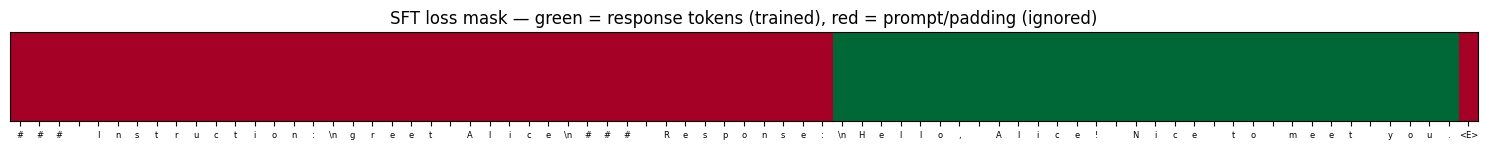

In [7]:
# Visualize the mask: which positions actually contribute to the loss?
supervised = (Y[0] >= 0).int().cpu().numpy()[None, :]
_label = {PAD_ID: '·', END_ID: '<E>', tokenizer.encode('\n')[0]: '\\n'}
chars = [_label.get(t, tokenizer.decode([t])) for t in X[0].cpu().tolist()]

fig, ax = plt.subplots(figsize=(15, 1.6))
ax.imshow(supervised, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(chars)))
ax.set_xticklabels(chars, fontsize=6)
ax.set_yticks([])
ax.set_title('SFT loss mask — green = response tokens (trained), red = prompt/padding (ignored)')
plt.tight_layout(); plt.show()

## Step 4: The SFT training loop

The loop is exactly the pretraining loop from notebook 08 — AdamW, gradient clipping,
cross-entropy — the *only* difference is the masked, instruction-formatted data. We start
from a `deepcopy` of the base model so we can compare against it afterwards.

In [8]:
def sft_train(model, X, Y, steps=400, lr=5e-4):
    params = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.AdamW(params, lr=lr)
    model.train(); losses = []; t0 = time.time()
    for s in range(steps):
        _, loss = model(X, Y)
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(params, 1.0); opt.step()
        losses.append(loss.item())
    print(f"SFT done in {time.time()-t0:.1f}s, final loss {losses[-1]:.3f}")
    return losses

sft_model = copy.deepcopy(base_model)
sft_losses = sft_train(sft_model, X, Y, steps=400)

SFT done in 11.9s, final loss 0.005


In [9]:
def accuracy(model):
    return sum(respond(model, i).strip() == r.strip() for i, r in examples) / len(examples)

print('Before SFT:', repr(respond(base_model, 'greet Alice')))
print('After  SFT:', repr(respond(sft_model,  'greet Alice')))
print('After  SFT:', repr(respond(sft_model,  'thank Bob')))
acc_full = accuracy(sft_model)
print(f'\nFormat-following accuracy on the toy set: {acc_full:.0%}')
assert acc_full >= 0.8, "SFT failed to teach the instruction format"
print('PASS: the base model is now an instruction-follower.')

Before SFT: 'AM\nAM\nAM\nAGONo the ou thou hou hou thou he the hou the the h'
After  SFT: 'Hello, Alice! Nice to meet you.'


After  SFT: 'Thank you, Bob, for your help.'



Format-following accuracy on the toy set: 100%
PASS: the base model is now an instruction-follower.


The same transformer, the same loss — but by reframing the *data* as masked
(instruction, response) pairs, it learned to answer. That is all SFT is.

## Step 5: The cost problem → parameter-efficient fine-tuning

Full fine-tuning updates **every** weight in the model and stores optimizer state
(momentum + variance for AdamW) for each one. For a 7-billion-parameter model that is
tens of gigabytes of GPU memory per fine-tune, and a full-size checkpoint for *every*
task you train.

**LoRA** (Low-Rank Adaptation) fixes this. The insight: the *change* a fine-tune makes to
a weight matrix is typically **low-rank**. So instead of updating $W$ directly, we freeze
it and learn a small low-rank update:

$$ W' = W + \frac{\alpha}{r}\, B A , \qquad A \in \mathbb{R}^{r \times d_{in}},\;\; B \in \mathbb{R}^{d_{out} \times r}, \quad r \ll d $$

Only $A$ and $B$ train. With $B$ initialized to **zero**, the adapter starts as a no-op,
so training begins exactly at the base model.

## Step 6: LoRA from scratch

We wrap an existing `nn.Linear` with a `LoRALinear` module that adds the low-rank path.

In [10]:
class LoRALinear(nn.Module):
    # Wrap a frozen nn.Linear with a trainable low-rank update B @ A.
    def __init__(self, base: nn.Linear, r=16, alpha=32, dropout=0.0):
        super().__init__()
        self.base = base
        for p in self.base.parameters():
            p.requires_grad_(False)                 # freeze the original weights
        self.r = r
        self.scaling = alpha / r
        self.lora_A = nn.Parameter(torch.randn(r, base.in_features) * 0.01)
        self.lora_B = nn.Parameter(torch.zeros(base.out_features, r))   # zero -> starts as no-op
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        return self.base(x) + (self.drop(x) @ self.lora_A.t() @ self.lora_B.t()) * self.scaling

    def merged_weight(self):
        # Fold the adapter back into a single weight matrix (zero-overhead inference).
        return self.base.weight.data + (self.lora_B @ self.lora_A) * self.scaling

In [11]:
# Inject LoRA into the attention (W_q/W_k/W_v/W_o) and feed-forward (linear1/linear2) layers,
# then freeze everything except the LoRA parameters.
LORA_TARGETS = {'W_q', 'W_k', 'W_v', 'W_o', 'linear1', 'linear2'}

def apply_lora(model, r=16, alpha=32):
    for module in model.modules():
        for name, child in list(module.named_children()):
            if isinstance(child, nn.Linear) and name in LORA_TARGETS:
                setattr(module, name, LoRALinear(child, r=r, alpha=alpha))
    for n, p in model.named_parameters():
        p.requires_grad_('lora_' in n)              # only LoRA params train
    return model

lora_model = apply_lora(copy.deepcopy(base_model), r=16, alpha=32)

total     = sum(p.numel() for p in lora_model.parameters())
trainable = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)
print(f"trainable: {trainable:,} / {total:,}  ({100*trainable/total:.1f}% of the model)")

trainable: 110,592 / 728,832  (15.2% of the model)


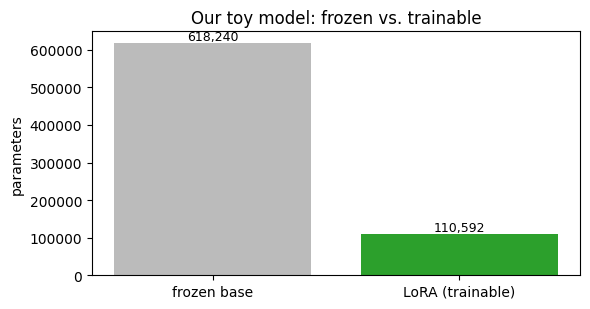

On our tiny 3-layer model LoRA is ~15% of params because the base itself is small.
On a real LLM the frozen base dwarfs the adapter — LoRA is typically <1% trainable.


In [12]:
# Why LoRA is a *big* deal at scale: the base is frozen, so trainable% shrinks as the
# model grows. The same r=16 adapter on a realistic model is a tiny fraction of it.
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.bar(['frozen base', 'LoRA (trainable)'], [total - trainable, trainable],
       color=['#bbbbbb', '#2ca02c'])
ax.set_ylabel('parameters'); ax.set_title('Our toy model: frozen vs. trainable')
for i, v in enumerate([total - trainable, trainable]):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

print("On our tiny 3-layer model LoRA is ~15% of params because the base itself is small.")
print("On a real LLM the frozen base dwarfs the adapter — LoRA is typically <1% trainable.")

## Step 7: Train with LoRA, then merge

We run the *same* SFT loop — but now only the LoRA parameters receive gradients. The
frozen base provides all the linguistic machinery; the adapter just steers it toward the
instruction format.

In [13]:
lora_losses = sft_train(lora_model, X, Y, steps=600, lr=1e-3)
acc_lora = accuracy(lora_model)
print('LoRA output for "greet Cara":', repr(respond(lora_model, 'greet Cara')))
print(f'LoRA format-following accuracy: {acc_lora:.0%}  (training only {100*trainable/total:.1f}% of params)')
assert acc_lora >= 0.8, "LoRA failed to learn the task"
print('PASS: LoRA matched full fine-tuning on this task.')

SFT done in 20.9s, final loss 0.286


LoRA output for "greet Cara": 'Hello, Cara! Nice to meet you.'
LoRA format-following accuracy: 100%  (training only 15.2% of params)
PASS: LoRA matched full fine-tuning on this task.


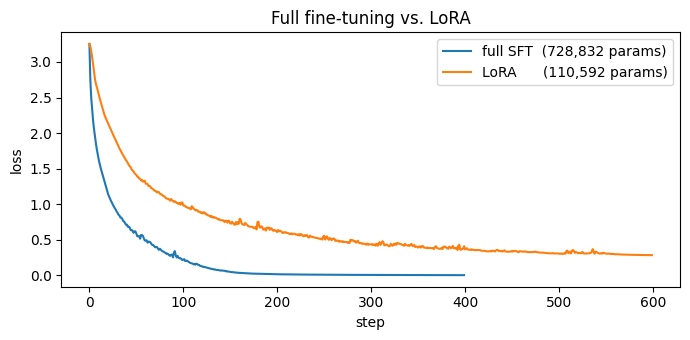

In [14]:
# Compare the two training curves.
plt.figure(figsize=(7, 3.5))
plt.plot(sft_losses,  label=f'full SFT  ({total:,} params)')
plt.plot(lora_losses, label=f'LoRA      ({trainable:,} params)')
plt.xlabel('step'); plt.ylabel('loss'); plt.title('Full fine-tuning vs. LoRA')
plt.legend(); plt.tight_layout(); plt.show()

In [15]:
# Merging: fold B@A back into the base weight so inference has ZERO extra cost.
some_lora = next(m for m in lora_model.modules() if isinstance(m, LoRALinear))
x = torch.randn(2, 5, some_lora.base.in_features, device=device)
with torch.no_grad():
    out_adapter = some_lora(x)                                        # base + LoRA path
    out_merged  = F.linear(x, some_lora.merged_weight(), some_lora.base.bias)  # single matmul
max_diff = (out_adapter - out_merged).abs().max().item()
print(f'max difference between adapter and merged weight: {max_diff:.2e}')
assert torch.allclose(out_adapter, out_merged, atol=1e-5)
print('PASS: a merged LoRA model is mathematically identical, with no inference overhead.')

max difference between adapter and merged weight: 5.96e-07
PASS: a merged LoRA model is mathematically identical, with no inference overhead.


## Summary

### Key Takeaways
- **SFT is just pretraining with different data.** Same transformer, same cross-entropy
  loss — we only reshape the data into *(instruction, response)* pairs.
- **Loss masking is the core trick.** Labeling prompt/padding positions with `-1`
  (`ignore_index`) trains the model on the *response only* — it learns to answer, not to
  parrot the question.
- **The format markers matter.** `### Response:\n` (or a real special token) is the cue
  the model learns to associate with "an answer goes here," including when to **stop**.
- **LoRA makes fine-tuning cheap.** Freeze $W$, learn a low-rank $\frac{\alpha}{r}BA$.
  Initializing $B=0$ means training starts at the base model; only a tiny fraction of
  parameters update, and the adapter can be **merged** for zero-overhead inference.
- LoRA's trainable fraction shrinks as the base grows — on real LLMs it is typically
  **<1%**, which is why a single GPU can fine-tune huge models.

### What's next
SFT teaches the model *a* correct format, but not *which* of several valid answers humans
actually prefer (more helpful? more polite? safer?). That is the job of **preference
alignment** — reward models, RLHF, and DPO — in **`13_preference_alignment.ipynb`**.

### References
- [InstructGPT — Ouyang et al., 2022](https://arxiv.org/abs/2203.02155) — SFT + RLHF pipeline
- [LoRA — Hu et al., 2021](https://arxiv.org/abs/2106.09685) — low-rank adaptation
- [QLoRA — Dettmers et al., 2023](https://arxiv.org/abs/2305.14314) — LoRA on a 4-bit quantized base